In [1]:
# Standard libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

Shape: (41202, 13)


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
0,2,1,17.63,2,1,132,164,1,70.0,0.5,6.94,1,16.54
1,2,1,19.52,2,1,132,236,1,70.0,0.5,6.94,1,16.19
2,2,1,17.81,2,1,132,48,1,70.0,0.5,6.94,1,12.00
3,2,2,19.30,2,1,132,148,1,70.0,0.5,0.00,1,5.00
4,2,1,18.75,2,1,132,234,1,70.0,0.5,6.94,1,10.00


<class 'pandas.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
count,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000
mean,2.0,1.633926,18.384928,2.025411,0.999393,132.220475,164.546333,1.0,69.986150,0.491020,5.608198,0.999976,14.107666
std,0.0,0.924250,2.856605,0.461587,0.024625,7.726159,67.901529,0.0,6.184851,0.066404,2.979348,0.004927,5.030619
min,2.0,1.000000,0.000000,1.000000,0.000000,10.000000,3.000000,1.0,3.700000,0.000000,0.000000,0.000000,0.010000
25%,2.0,1.000000,17.370000,2.000000,1.000000,132.000000,113.000000,1.0,70.000000,0.500000,6.940000,1.000000,10.000000
50%,2.0,1.000000,18.180000,2.000000,1.000000,132.000000,163.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
75%,2.0,2.000000,19.380000,2.000000,1.000000,132.000000,231.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
max,2.0,8.000000,189.910000,5.000000,1.000000,264.000000,265.000000,1.0,199.700000,0.500000,57.000000,1.000000,98.000000



Missing values:
VendorID                 0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
mta_tax                  0
tolls_amount             0
improvement_surcharge    0
tip_amount               0
dtype: int64


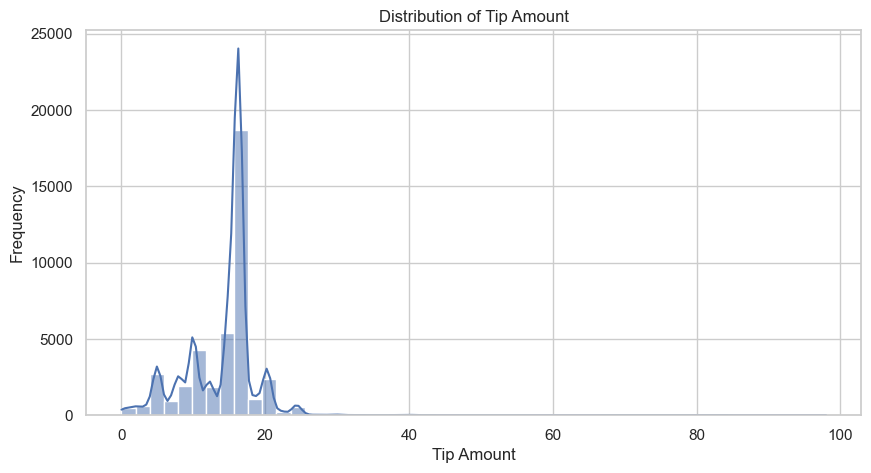


Percentage of zero tips: 0.00%
Max tip: $98.00


In [5]:
#Part 1.1 — Load and explore the taxi data


TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
taxi = pd.read_csv(TAXI_URL)


# Inspect the data
print("Shape:", taxi.shape)
display(taxi.head())
taxi.info()
display(taxi.describe())
print("\nMissing values:")
print(taxi.isna().sum())

# Visualise target distribution
plt.figure(figsize=(10, 5))
sns.histplot(taxi['tip_amount'], bins=50, kde=True)
plt.title('Distribution of Tip Amount')
plt.xlabel('Tip Amount')
plt.ylabel('Frequency')
plt.show()

print(f"\nPercentage of zero tips: {(taxi['tip_amount'] == 0).mean() * 100:.2f}%")
print(f"Max tip: ${taxi['tip_amount'].max():.2f}")

In [18]:
#Part 1.2 — Preprocessing & feature engineering
# TODO: Handle missing / invalid rows
#   e.g. drop or impute NaNs; remove rows where trip_distance <= 0 or fare_amount <= 0;
#   decide how to treat negative tip_amount values.

import pandas as pd

# 1. Handle missing / invalid rows
taxi = taxi.dropna()                                
taxi = taxi[taxi["trip_distance"] > 0]              
taxi = taxi[taxi["fare_amount"] > 0]                
taxi = taxi[taxi["tip_amount"] >= 0]  


# TODO: Feature engineering — create at least ONE new, justified feature, for example:
#   - tip_rate proxy, fare-per-mile = fare_amount / trip_distance
#   - total surcharges = mta_tax + tolls_amount + improvement_surcharge
#   (Careful: do NOT leak the target. Do not build features directly from tip_amount.)

taxi["fare_per_mile"] = taxi["fare_amount"] / taxi["trip_distance"]
taxi["total_surcharges"] = taxi["mta_tax"] + taxi["tolls_amount"] + taxi["improvement_surcharge"]

# Remove infinite values
taxi = taxi[~taxi["fare_per_mile"].isin([float('inf'), float('-inf')])]

# 3. Separate features (X) and target (y)
X_taxi = taxi.drop("tip_amount", axis=1)
y_taxi = taxi["tip_amount"]

# 4. NO ENCODING NEEDED — columns are already numeric
# Just use X_taxi as is.
X_taxi = X_taxi.copy()


print(f"Features shape: {X_taxi.shape}")
print(f"Target shape: {y_taxi.shape}")
print(X_taxi.head())

Features shape: (41126, 270)
Target shape: (41126,)
   passenger_count  trip_distance  fare_amount  mta_tax  tolls_amount  \
0                1          17.63         70.0      0.5          6.94   
1                1          19.52         70.0      0.5          6.94   
2                1          17.81         70.0      0.5          6.94   
3                2          19.30         70.0      0.5          0.00   
4                1          18.75         70.0      0.5          6.94   

   improvement_surcharge  fare_per_mile  total_surcharges  RatecodeID_2  \
0                      1       3.970505              8.44          True   
1                      1       3.586066              8.44          True   
2                      1       3.930376              8.44          True   
3                      1       3.626943              1.50          True   
4                      1       3.733333              8.44          True   

   RatecodeID_4  RatecodeID_5  store_and_fwd_flag_1  PULoc

In [62]:
#Part 1.3 — Train / Validation / Test split


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# TODO: Separate features (X) and target (y = tip_amount)

X = X_taxi_encoded  # Already defined in Part 1.2
y = y_taxi           # Already defined in Part 1.2


# TODO: Split into train / validation / test (a common choice is 60/20/20).
#   from sklearn.model_selection import train_test_split
#   First split off the test set, then split the remainder into train + validation.
#   Use random_state=RANDOM_STATE.
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=RANDOM_STATE
)

# Then split the remainder into train (75% of 80% = 60% total) and validation (25% of 80% = 20% total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, 
    test_size=0.25,   # 0.25 of 80% = 20% total
    random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape[0]} rows")
print(f"Validation: {X_val.shape[0]} rows")
print(f"Test: {X_test.shape[0]} rows")

# TODO: Fit your scaler on the TRAINING set only, then transform train, val, and test.
#   (Explain in the reasoning box why scaling must be fit on train only.)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

# Then transform validation and test sets using the SAME scaler
X_val = scaler.transform(X_val)
X_test= scaler.transform(X_test)


print(f"Train shape: {X_train.shape}")
print(f"Val shape:   {X_val.shape}")
print(f"Test shape:  {X_test.shape}")

Train: 24675 rows
Validation: 8225 rows
Test: 8226 rows
Train shape: (24675, 270)
Val shape:   (8225, 270)
Test shape:  (8226, 270)



Linear Regression
  Train: RMSE=1.6950, R²=0.2456
  Validation: RMSE=1.7093, R²=0.2351
  Test: RMSE=1.7349, R²=0.2076

Random Forest
  Train: RMSE=0.1298, R²=0.9956
  Validation: RMSE=0.3054, R²=0.9756
  Test: RMSE=0.2994, R²=0.9764


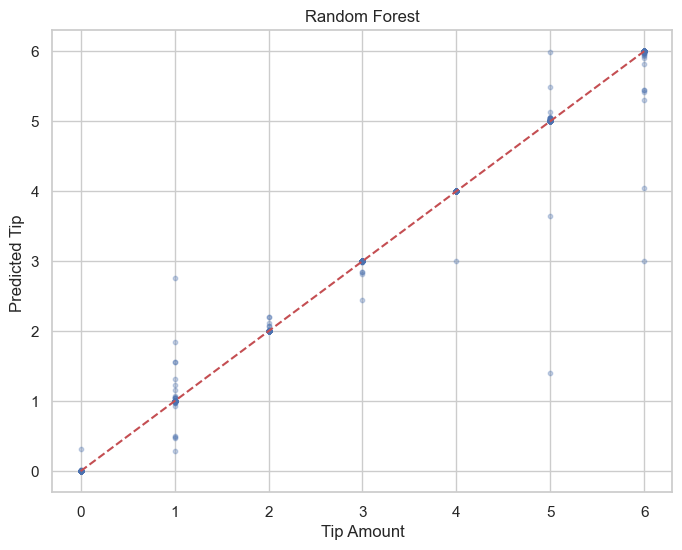

In [61]:
#Part 1.4 — Train a regressor and check for overfitting

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt


# TODO: Import, initialise, and train a regression model.
#   Start simple (LinearRegression), then try a more flexible model
#   (e.g. RandomForestRegressor or DecisionTreeRegressor) and compare.

# Train Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)


# TODO: Predict on train, validation, and test sets.
# Evaluate both models
models = [("Linear Regression", lr), ("Random Forest", rf)]

# TODO: Report RMSE and R^2 for ALL THREE sets.
#   from sklearn.metrics import mean_squared_error, r2_score
#   (RMSE = mean_squared_error(y_true, y_pred) ** 0.5)

for name, model in models:
    print(f"\n{name}")
    for X_set, y_set, label in [(X_train_scaled, y_train, "Train"),
                                 (X_val_scaled, y_val, "Validation"),
                                 (X_test_scaled, y_test, "Test")]:
        pred = model.predict(X_set)
        rmse = mean_squared_error(y_set, pred) ** 0.5
        r2 = r2_score(y_set, pred)
        print(f"  {label}: RMSE={rmse:.4f}, R²={r2:.4f}")

# TODO: Plot predicted vs actual tip for the test set (a scatter with the y=x line).
# Plot: Random Forest 
y_pred = rf.predict(X_test_scaled)
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.3, s=10)
plt.plot([0, max(y_test)], [0, max(y_test)], 'r--')
plt.xlabel("Tip Amount")
plt.ylabel("Predicted Tip ")
plt.title("Random Forest")
plt.show()

Shape: (2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000



Missing values:
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

Class distribution:
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


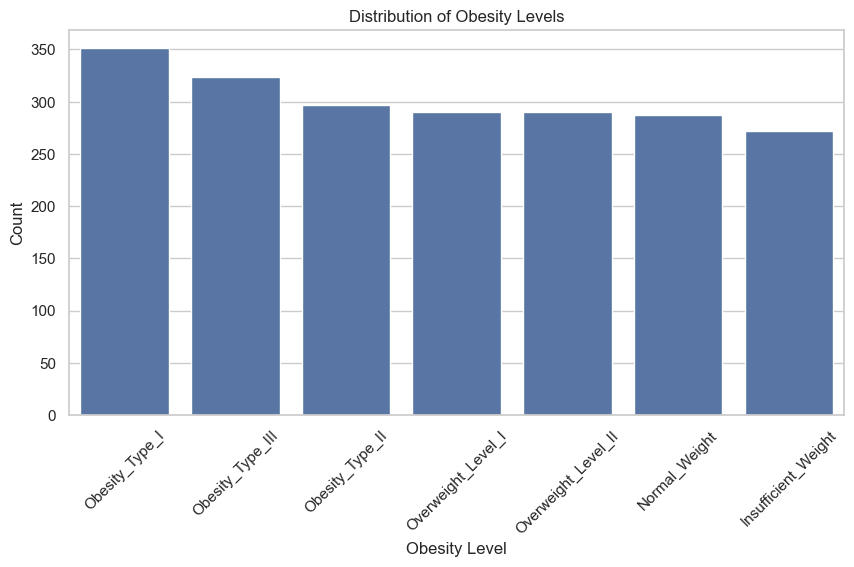


Class balance (proportions):
NObeyesdad
Obesity_Type_I         16.6
Obesity_Type_III       15.3
Obesity_Type_II        14.1
Overweight_Level_I     13.7
Overweight_Level_II    13.7
Normal_Weight          13.6
Insufficient_Weight    12.9
Name: proportion, dtype: float64


In [60]:
#Part 2.1 — Load and explore the obesity data


# TODO: Load the obesity dataset from OBESITY_URL into a DataFrame called `obesity`
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
obesity = pd.read_csv(OBESITY_URL)

# TODO: Inspect shape, head, info, describe, and missing values.

print("Shape:", obesity.shape)
display(obesity.head())
obesity.info()
display(obesity.describe())
print("\nMissing values:")
print(obesity.isna().sum())

# TODO: Show the class distribution of `NObeyesdad`
print("\nClass distribution:")
print(obesity['NObeyesdad'].value_counts())

#   (value_counts and a sns.countplot). Is it balanced across the 7 classes?
plt.figure(figsize=(10, 5))
sns.countplot(data=obesity, x='NObeyesdad', order=obesity['NObeyesdad'].value_counts().index)
plt.title('Distribution of Obesity Levels')
plt.xlabel('Obesity Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Check class balance
print("\nClass balance (proportions):")
print(obesity['NObeyesdad'].value_counts(normalize=True).round(3) * 100)

In [59]:
#Part 2.2 — Preprocessing & feature engineering


# TODO: Encode categorical columns.
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

#   - Binary yes/no columns (family_history_with_overweight, FAVC, SMOKE, SCC) -> 0/1
binary_map = {"yes": 1, "no": 0}
for col in ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']:
    if col in obesity.columns:
        obesity[col] = obesity[col].map(binary_map)

        
#   - Ordinal-ish columns (CAEC, CALC) and nominal (Gender, MTRANS) -> choose an encoding
caec_map = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}
calc_map = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}
if 'CAEC' in obesity.columns:
    obesity["CAEC"] = obesity["CAEC"].map(caec_map)
if 'CALC' in obesity.columns:
    obesity["CALC"] = obesity["CALC"].map(calc_map)

#     and justify it (LabelEncoder / OrdinalEncoder / pd.get_dummies / OneHotEncoder).

# TODO (optional but encouraged): engineer a domain feature, e.g. BMI = Weight / Height**2.
#   Discuss whether including BMI makes the task "too easy" / leaks the target.

obesity["BMI"] = obesity["Weight"] / (obesity["Height"] ** 2)


# TODO: Encode the target `NObeyesdad` into integer class labels
X_obesity = obesity.drop("NObeyesdad", axis=1)
y_obesity = LabelEncoder().fit_transform(obesity["NObeyesdad"])


binary_cols  = [c for c in ['family_history_with_overweight','FAVC','SMOKE','SCC'] if c in X_obesity.columns]
ordinal_cols = [c for c in ['CAEC','CALC'] if c in X_obesity.columns]
nominal_cols = [c for c in ['Gender','MTRANS'] if c in X_obesity.columns]  
numeric_cols = [c for c in ['Age','Height','Weight','FCVC','NCP','CH2O','FAF','TUE','BMI'] if c in X_obesity.columns]

print("Binary:", binary_cols)
print("Ordinal:", ordinal_cols)
print("Nominal:", nominal_cols)
print("Numeric:", numeric_cols)

# TODO: Scale the numeric features (fit on TRAIN only, in Part 2.3).

preprocessor = ColumnTransformer([
    ("binary", "passthrough", binary_cols),
    ("ordinal", "passthrough", ordinal_cols),
    ("nominal", OneHotEncoder(drop="first"), nominal_cols),
    ("numeric", StandardScaler(), numeric_cols)
])

# 7. Fit and transform
X_obesity_processed = preprocessor.fit_transform(X_obesity)

print("Shape after preprocessing:", X_obesity_processed.shape)


Binary: ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
Ordinal: ['CAEC', 'CALC']
Nominal: []
Numeric: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'BMI']
Shape after preprocessing: (2111, 15)


In [58]:
#Part 2.3 — Stratified Train / Validation / Test split


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')   

# TODO: Separate X (features) and y (encoded NObeyesdad).
#  Removing constant columns 
constant_cols = [col for col in X_obesity.columns if X_obesity[col].nunique() <= 1]
if constant_cols:
    print(f"Dropping constant columns: {constant_cols}")
    X_obesity = X_obesity.drop(columns=constant_cols)

# Removing rows where Height is zero 
X_obesity = X_obesity[X_obesity['Height'] > 0]
y_obesity = y_obesity[X_obesity.index]   # align target

# TODO: Split into train / validation / test using stratify=y so every split has all 7 classes.
#   Use random_state=RANDOM_STATE.
X_temp, X_test, y_temp, y_test = train_test_split(
    X_obesity, y_obesity, test_size=0.2, random_state=42, stratify=y_obesity
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

# TODO: Fit the scaler on the training set only, then transform train / val / test.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


Train: 1266, Val: 422, Test: 423


Train        - Accuracy: 1.0000, Macro-F1: 1.0000
Validation   - Accuracy: 0.9834, Macro-F1: 0.9828
Test         - Accuracy: 0.9905, Macro-F1: 0.9901


<Figure size 1000x800 with 0 Axes>

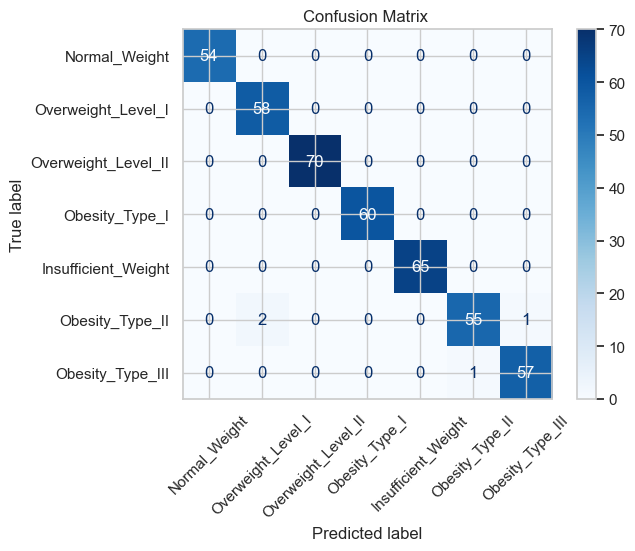


Classification Report 
                     precision    recall  f1-score   support

      Normal_Weight       1.00      1.00      1.00        54
 Overweight_Level_I       0.97      1.00      0.98        58
Overweight_Level_II       1.00      1.00      1.00        70
     Obesity_Type_I       1.00      1.00      1.00        60
Insufficient_Weight       1.00      1.00      1.00        65
    Obesity_Type_II       0.98      0.95      0.96        58
   Obesity_Type_III       0.98      0.98      0.98        58

           accuracy                           0.99       423
          macro avg       0.99      0.99      0.99       423
       weighted avg       0.99      0.99      0.99       423



In [57]:
#Part 2.4 — Train a classifier and check for overfitting

# TODO: Import, initialise, and train a classifier
#   (e.g. LogisticRegression(max_iter=...), RandomForestClassifier, or KNeighborsClassifier)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

# TODO: Predict on train, validation, and test.
# 1. Train Random Forest
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_scaled, y_train)

# 2. Predict
y_train_pred = clf.predict(X_train_scaled)
y_val_pred = clf.predict(X_val_scaled)
y_test_pred = clf.predict(X_test_scaled)


# TODO: Report accuracy AND macro-F1 for ALL THREE sets
#   from sklearn.metrics import accuracy_score, f1_score, classification_report
for name, y_true, y_pred in [
    ('Train', y_train, y_train_pred),
    ('Validation', y_val, y_val_pred),
    ('Test', y_test, y_test_pred)
]:
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    print(f"{name:12} - Accuracy: {acc:.4f}, Macro-F1: {f1:.4f}")

# TODO: Show a confusion matrix for the test set
#   from sklearn.metrics import ConfusionMatrixDisplay
#   Which classes are most often confused?

plt.figure(figsize=(10, 8))

if hasattr(le, 'classes_'):
    class_labels = le.classes_
else:
    class_labels = obesity['NObeyesdad'].unique()

ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred,
    display_labels=class_labels,
    xticks_rotation=45,
    cmap='Blues'
)
plt.title('Confusion Matrix ')
plt.show()

# 5. Classification report
print("\nClassification Report ")
print(classification_report(y_test, y_test_pred, target_names=class_labels))

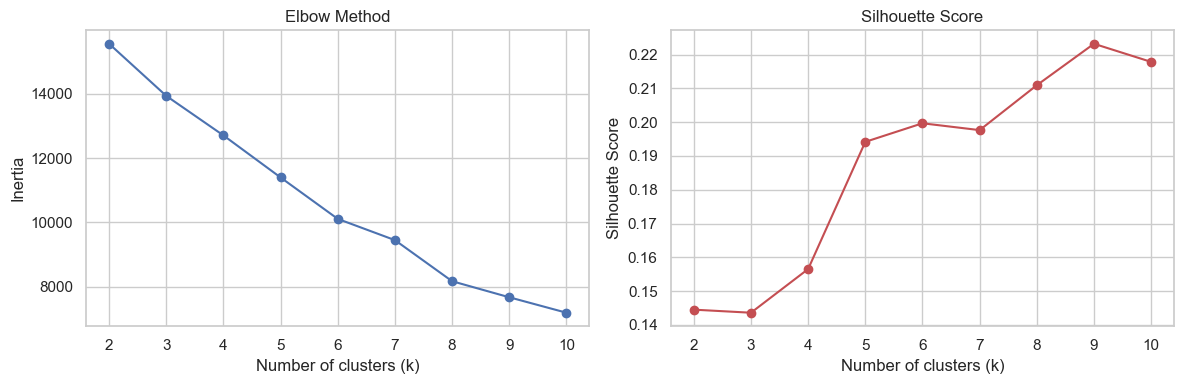

 K-Means clustering complete with k=10


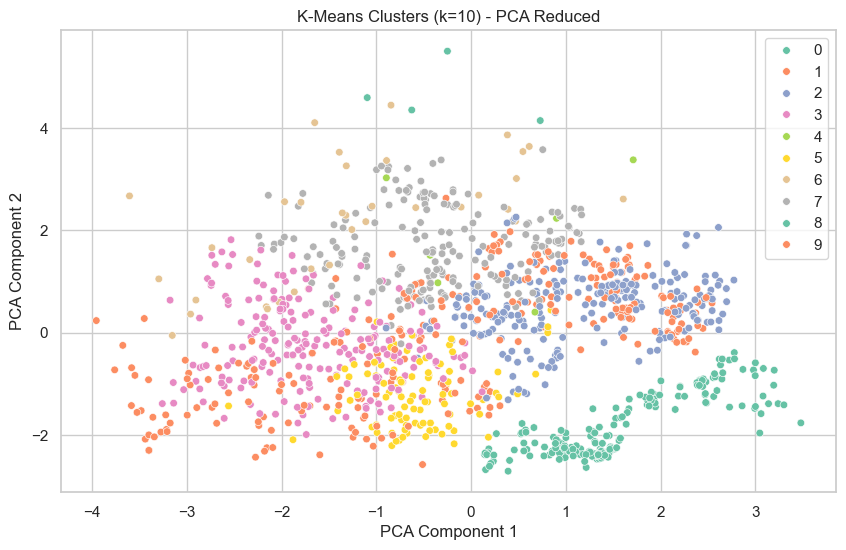


Cluster vs True Obesity Level (Training set):
NObeyesdad  Insufficient_Weight  Normal_Weight  Obesity_Type_I  \
row_0                                                            
0                             0              0               0   
1                             0              4              31   
2                             0              3              74   
3                            72             51              30   
4                             0              4               2   
5                             0              6              33   
6                             4             19               1   
7                            58             55              13   
8                             0              4               0   
9                            29             26              27   

NObeyesdad  Obesity_Type_II  Obesity_Type_III  Overweight_Level_I  \
row_0                                                               
0                     

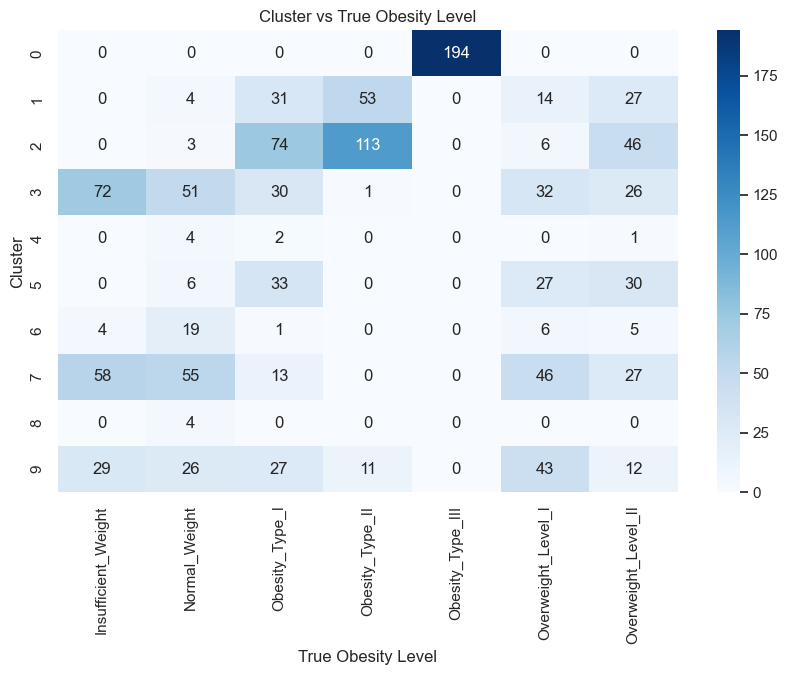

In [56]:
#Section 3 — Unsupervised Learning: K-Means Clustering
# TODO: Use ONLY the scaled obesity features (no target) for clustering.
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


X_cluster = X_train_scaled  
# 2. Find best k using Elbow and Silhouette
inertias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster, km.labels_))

# TODO: Choose the number of clusters k with the Elbow method (and/or silhouette score).
#   from sklearn.cluster import KMeans
#   from sklearn.metrics import silhouette_score
#   Loop k = 2..10, record inertia_ (and silhouette), and plot inertia vs k.

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouettes, 'ro-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')

plt.tight_layout()
plt.show()

#TODO: Fit KMeans with your chosen k (random_state=RANDOM_STATE) and get cluster labels
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster)

print(f" K-Means clustering complete with k={k}")

# TODO: Visualise the clusters in 2D.
#   Pick two informative features (e.g. Weight vs Height) OR reduce to 2D with PCA
#   (from sklearn.decomposition import PCA) and colour points by cluster.
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=cluster_labels, palette='Set2', s=30)
plt.title(f'K-Means Clusters (k={k}) - PCA Reduced')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()


crosstab = pd.crosstab(cluster_labels, obesity.loc[X_train.index, 'NObeyesdad'])
print("\nCluster vs True Obesity Level (Training set):")
print(crosstab)

# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues')
plt.title('Cluster vs True Obesity Level')
plt.xlabel('True Obesity Level')
plt.ylabel('Cluster')
plt.show()


Cluster vs True Obesity Level (Training set):
NObeyesdad  Insufficient_Weight  Normal_Weight  Obesity_Type_I  \
row_0                                                            
0                             4             19               1   
1                           106             79              57   
2                             0              0               0   
3                            53             56              89   
4                             0             14              64   
5                             0              4               0   

NObeyesdad  Obesity_Type_II  Obesity_Type_III  Overweight_Level_I  \
row_0                                                               
0                         0                 0                   6   
1                         0                 0                  73   
2                        20               194                   0   
3                        99                 0                  59   
4         

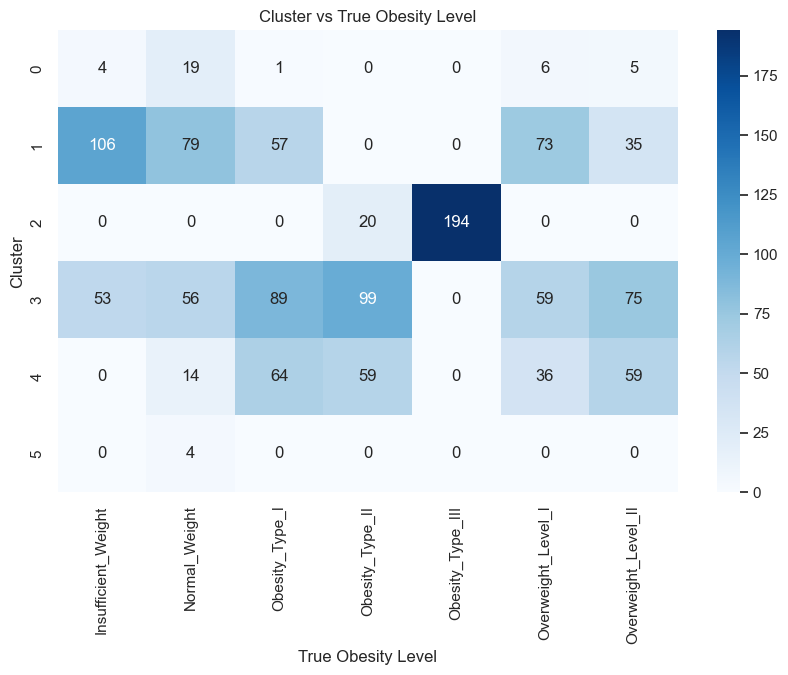


Cluster mapping:
Cluster 0: mostly 'Normal_Weight' (19/35 = 54.3%)
Cluster 1: mostly 'Insufficient_Weight' (106/350 = 30.3%)
Cluster 2: mostly 'Obesity_Type_III' (194/214 = 90.7%)
Cluster 3: mostly 'Obesity_Type_II' (99/431 = 23.0%)
Cluster 4: mostly 'Obesity_Type_I' (64/232 = 27.6%)
Cluster 5: mostly 'Normal_Weight' (4/4 = 100.0%)


In [53]:
# TODO: How well do the clusters line up with the TRUE obesity levels?
#  Build a crosstab of cluster label vs the real NObeyesdad category:
crosstab = pd.crosstab(cluster_labels, obesity.loc[X_train.index, 'NObeyesdad'])
print("\nCluster vs True Obesity Level (Training set):")
print(crosstab)

# Do some clusters map cleanly onto specific obesity levels?
# Heatmap for visual comparison
plt.figure(figsize=(10, 6))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues')
plt.title('Cluster and True Obesity Level')
plt.xlabel('True Obesity Level')
plt.ylabel('Cluster')
plt.show()

# Which clusters map cleanly?
print("\nCluster mapping:")
for cluster in range(k):
    top_class = crosstab.loc[cluster].idxmax()
    count = crosstab.loc[cluster].max()
    total = crosstab.loc[cluster].sum()
    print(f"Cluster {cluster}: mostly '{top_class}' ({count}/{total} = {count/total:.1%})")